# Лабораторна робота 5 — Логістична регресія для аналізу тональності

**Набори даних:** `amazon_baby_subset.csv`, `important_words.json`  
**Обмеження:** scikit-learn-класифікатори **не дозволені** для базових завдань.

## Налаштування

In [1]:
import sys
!{sys.executable} -m pip install numpy pandas matplotlib --quiet


In [3]:
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt

%matplotlib inline


## Теоретичне підґрунтя

Сигмоїдна функція:
```
P(y = +1 | x, w) = 1 / (1 + exp(−wᵀ h(x)))
```
Похідна логарифму правдоподібності відносно wⱼ:
```
d(ll)/dwⱼ = dot( hⱼ,  1[y=+1] − P(y=+1|x,w) )
```
де 1[y=+1] = 1, якщо мітка +1, інакше 0.

---
## Завдання 1 — Підготовка ознак

1. Завантажте `amazon_baby_subset.csv`. Видаліть рядки з відсутніми відгуками. Вилучіть відгуки з `rating == 3`. Створіть стовпець `sentiment`: **+1** якщо `rating >= 4`, інакше **−1**.
2. Завантажте `important_words.json` (193 слова). Для кожного слова додайте стовпець до DataFrame із підрахунком його входжень у очищений текст відгуку.
3. Повідомте, скільки відгуків залишилось та який баланс класів.

In [23]:
# Завантаження набору даних
products = pd.read_csv('amazon_baby.csv')

# Видаліть рядки з відсутніми відгуками та нейтральними рейтингами
products = products.dropna(subset=['review'])
products = products[products['rating'] != 3].reset_index(drop=True)

# Створіть стовпець sentiment: +1 якщо рейтинг >= 4, інакше -1
products['sentiment'] = products['rating'].apply(lambda r: +1 if r >= 4 else -1)

print(f'Усього відгуків : {len(products)}')
print(f'Позитивні (+1)  : {(products["sentiment"] == 1).sum()}')
print(f'Негативні (-1)  : {(products["sentiment"] == -1).sum()}')


Усього відгуків : 165975
Позитивні (+1)  : 139582
Негативні (-1)  : 26393


In [24]:
# Завантаження важливих слів
with open('important_words.json') as f:
    important_words = json.load(f)
print(f'Розмір словника: {len(important_words)} слів')


Розмір словника: 193 слів


In [25]:
# Очищення тексту відгуків (видалення пунктуації, приведення до нижнього регістру)
import string
products['review_clean'] = (
    products['review']
    .fillna('')
    .str.replace(f'[{string.punctuation}]', '', regex=True)
    .str.lower()
)

# Додайте стовпець підрахунку слів для кожного важливого слова
for word in important_words:
    products[word] = products['review_clean'].apply(
        lambda text: text.split().count(word)
    )

print('Приклад підрахунку слів:')
products[important_words[:5]].head(4)


C:\Users\Admin\AppData\Local\Temp\ipykernel_12652\4152833537.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  products[word] = products['review_clean'].apply(
C:\Users\Admin\AppData\Local\Temp\ipykernel_12652\4152833537.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  products[word] = products['review_clean'].apply(
C:\Users\Admin\AppData\Local\Temp\ipykernel_12652\4152833537.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor perform

Приклад підрахунку слів:


C:\Users\Admin\AppData\Local\Temp\ipykernel_12652\4152833537.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  products[word] = products['review_clean'].apply(


,baby,one,great,love,use
0,0,0,0,1,0
1,0,0,0,0,0
2,0,0,0,2,0
3,0,0,1,0,0


---
## Завдання 2 — Побудова матриці ознак

Реалізуйте `get_feature_matrix(df, word_list)`, яка:
1. Створює масив NumPy зі стовпцем одиниць (вільний член), за яким іде по одному стовпцю для кожного слова зі списку.
2. Повертає `(feature_matrix, sentiment_array)`, де `sentiment_array` містить +1 або −1.

Перевірка: `feature_matrix` має форму `(N, 194)`.

In [26]:
def get_feature_matrix(df, word_list):
    """
    Будує матрицю ознак та вектор міток тональності.

    Повертає
    -------
    feature_matrix  : np.ndarray, shape (n, len(word_list)+1)
    sentiment_array : np.ndarray, shape (n,)  значення {+1, -1}
    """
    # Intercept column of 1s
    intercept = np.ones((len(df), 1))

    # Word feature columns
    word_features = df[word_list].to_numpy()

    feature_matrix = np.hstack([intercept, word_features])
    sentiment_array = df['sentiment'].to_numpy()
    return feature_matrix, sentiment_array


In [27]:
feature_matrix, sentiment = get_feature_matrix(products, important_words)
print(f'Розмір feature_matrix: {feature_matrix.shape}')  # очікується (N, 194)


Розмір feature_matrix: (165975, 194)


---
## Завдання 3 — Сигмоїдна функція та передбачення

Реалізуйте `predict_probability(feature_matrix, coefficients)`, що обчислює сигмоїдну функцію для кожного рядка. Результат — масив NumPy зі значеннями у (0, 1).

In [28]:
def predict_probability(feature_matrix, coefficients):
    """
    Обчислює P(y = +1 | x, w) для кожного рядка.

    Повертає
    -------
    probabilities : np.ndarray, shape (n,), значення у (0, 1)
    """
    # Compute the linear score for each example
    score = np.dot(feature_matrix, coefficients)

    # Apply sigmoid
    probabilities = 1.0 / (1.0 + np.exp(-score))

    return probabilities


### Перевірка — при нульових вхідних даних кожне передбачення має дорівнювати 0.5

In [29]:
zero_coeffs = np.zeros(feature_matrix.shape[1])
test_probs  = predict_probability(feature_matrix, zero_coeffs)
print(f'Усі передбачення 0.5: {np.allclose(test_probs, 0.5)}')


Усі передбачення 0.5: True


---
## Завдання 4 — Градієнтний підйом

Реалізуйте `logistic_regression(feature_matrix, sentiment, initial_coefficients, step_size, max_iter)`. На кожній ітерації:
1. Обчислюйте передбачення за допомогою `predict_probability()`.
2. Обчислюйте `errors = 1[y=+1] − predictions`.
3. Для кожного коефіцієнта j: `derivative = dot(feature_j, errors)`, потім `coeff[j] += step_size · derivative`.

Запустіть з: `initial_coefficients = np.zeros(194)`, `step_size = 1e-7`, `max_iter = 301`. Виводьте логарифм правдоподібності кожні 50 ітерацій — він має зростати монотонно.

In [30]:
def compute_log_likelihood(feature_matrix, sentiment, coefficients):
    """Допоміжна функція (надана) — обчислює логарифм правдоподібності для моніторингу."""
    indicator = (sentiment == +1).astype(float)
    scores    = np.dot(feature_matrix, coefficients)
    ll        = np.sum(
        indicator * scores - np.log(1.0 + np.exp(scores))
    )
    return ll


In [31]:
def logistic_regression(feature_matrix, sentiment,
                        initial_coefficients, step_size, max_iter):
    """
    Навчає ваги логістичної регресії методом градієнтного підйому.

    Повертає
    -------
    coefficients : np.ndarray, shape (n_features,)
    """
    coefficients = np.array(initial_coefficients, dtype=float)
    indicator    = (sentiment == +1).astype(float)   # 1 if positive, 0 otherwise

    for itr in range(max_iter):
        # 1. Compute predictions P(y=+1 | x, w)
        predictions = predict_probability(feature_matrix, coefficients)

        # 2. Compute errors = indicator(y=+1) - predictions
        errors = indicator - predictions

        # 3. Update every coefficient
        for j in range(len(coefficients)):
            derivative = np.dot(feature_matrix[:, j], errors)
            coefficients[j] += step_size * derivative

        # Print log-likelihood every 50 iterations
        if itr % 50 == 0:
            ll = compute_log_likelihood(feature_matrix, sentiment, coefficients)
            print(f'Ітерація {itr:4d}  |  логарифм правдоподібності: {ll:.4f}')

    return coefficients


### Запуск моделі

In [42]:
coefficients = logistic_regression(
    feature_matrix, sentiment,
    initial_coefficients=np.zeros(194),
    step_size=1e-7,
    max_iter=301
)


Ітерація    0  |  логарифм правдоподібності: -114053.9611
Ітерація   50  |  логарифм правдоподібності: -89016.5126
Ітерація  100  |  логарифм правдоподібності: -80951.9493
Ітерація  150  |  логарифм правдоподібності: -77024.6590
Ітерація  200  |  логарифм правдоподібності: -74579.2559
Ітерація  250  |  логарифм правдоподібності: -72790.3045
Ітерація  300  |  логарифм правдоподібності: -71342.4474


### Точність класифікації та базовий рівень

In [41]:
# Передбачте мітки класів (+1 якщо score > 0, інакше -1)
scores          = np.dot(feature_matrix, coefficients)
predictions     = np.where(scores > 0, +1, -1)

# Точність моделі
model_accuracy  = np.mean(predictions == sentiment)
print(f'Точність моделі   : {model_accuracy:.4f}')

# Базовий рівень мажоритарного класу
majority_class  = +1 if (sentiment == +1).sum() >= (sentiment == -1).sum() else -1
baseline_acc    = np.mean(majority_class == sentiment)
print(f'Базовий рівень    : {baseline_acc:.4f}  (завжди передбачає {majority_class})')


Точність моделі   : 0.8410
Базовий рівень    : 0.8410  (завжди передбачає 1)


---
## ✨ Бонус — Інтерпретація моделі

Зіставте кожне слово з його навченим коефіцієнтом. Виведіть 10 слів з найбільшими коефіцієнтами та 10 слів з найменшими.

Для одного слова з кожного списку знайдіть відгук у наборі даних, що його містить, і вкажіть передбачувану ймовірність моделі.

=== Топ-10 найбільш ПОЗИТИВНИХ слів ===
   word  coefficient
  great     0.276783
   love     0.245464
   easy     0.207137
 little     0.153945
  loves     0.151165
   baby     0.140310
   well     0.128010
perfect     0.108582
    old     0.106762
    use     0.097039

=== Топ-10 найбільш НЕГАТИВНИХ слів ===
        word  coefficient
       money    -0.044581
disappointed    -0.040359
      return    -0.037400
       waste    -0.037210
     monitor    -0.031972
    returned    -0.023564
        work    -0.022328
     thought    -0.021802
       broke    -0.021068
        back    -0.018650


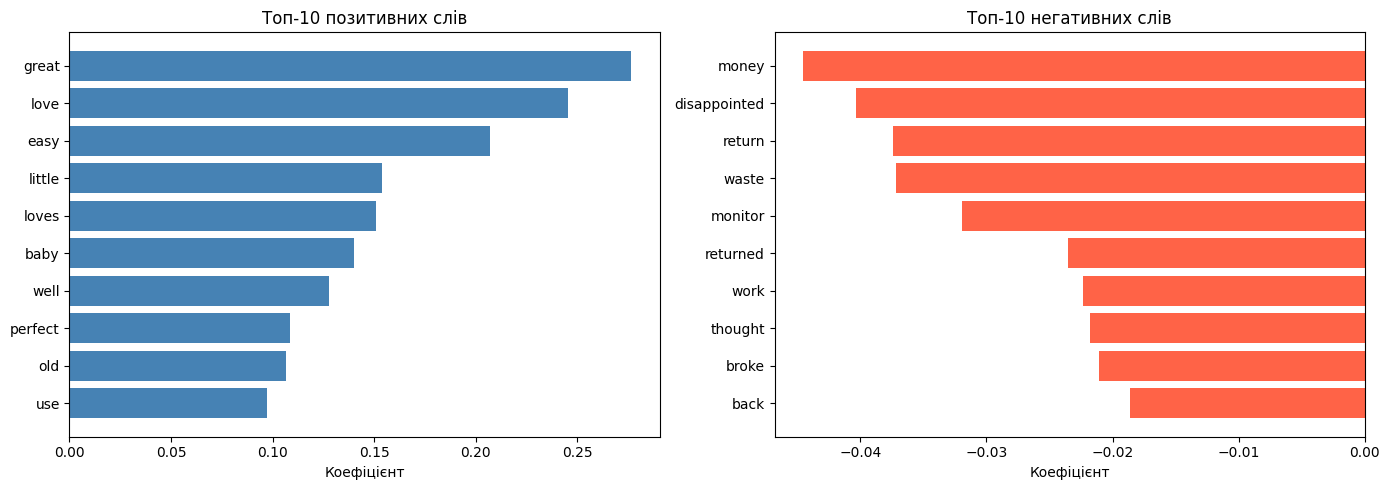

In [34]:
# Бонус — аналіз коефіцієнтів
# coefficients[0] — вільний член (intercept), coefficients[1:] — слова
coef_df = pd.DataFrame({
    'word': important_words,
    'coefficient': coefficients[1:]   # skip the intercept
})

top10_positive = coef_df.nlargest(10, 'coefficient')
top10_negative = coef_df.nsmallest(10, 'coefficient')

print('=== Топ-10 найбільш ПОЗИТИВНИХ слів ===')
print(top10_positive.to_string(index=False))

print('\n=== Топ-10 найбільш НЕГАТИВНИХ слів ===')
print(top10_negative.to_string(index=False))

# Візуалізація
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(top10_positive['word'], top10_positive['coefficient'], color='steelblue')
axes[0].set_title('Топ-10 позитивних слів')
axes[0].set_xlabel('Коефіцієнт')
axes[0].invert_yaxis()

axes[1].barh(top10_negative['word'], top10_negative['coefficient'], color='tomato')
axes[1].set_title('Топ-10 негативних слів')
axes[1].set_xlabel('Коефіцієнт')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


In [39]:
# Бонус — приклад відгуку з передбачуваною ймовірністю

# --- Приклад для найбільш позитивного слова ---
pos_word = top10_positive.iloc[0]['word']
pos_review_idx = products[products[pos_word] > 0].index[0]
pos_review_features = feature_matrix[pos_review_idx].reshape(1, -1)
pos_prob = predict_probability(pos_review_features, coefficients)[0]

print(f"Найбільш позитивне слово : '{pos_word}'")
print(f"Відгук (перші 200 символів): {products.loc[pos_review_idx, 'review'][:200]}")
print(f"P(y=+1 | x, w) = {pos_prob:.4f}")
print(f"Реальна мітка  : {products.loc[pos_review_idx, 'sentiment']}")

print()

pos_word = top10_positive.iloc[0]['word']
pos_review_idx = products[products[pos_word] > 0].index[1]
pos_review_features = feature_matrix[pos_review_idx].reshape(1, -1)
pos_prob = predict_probability(pos_review_features, coefficients)[0]

print(f"Найбільш позитивне слово : '{pos_word}'")
print(f"Відгук (перші 200 символів): {products.loc[pos_review_idx, 'review'][:200]}")
print(f"P(y=+1 | x, w) = {pos_prob:.4f}")
print(f"Реальна мітка  : {products.loc[pos_review_idx, 'sentiment']}")

print()

# --- Приклад для найбільш негативного слова ---
neg_word = top10_negative.iloc[0]['word']
neg_review_idx = products[products[neg_word] > 0].index[0]
neg_review_features = feature_matrix[neg_review_idx].reshape(1, -1)
neg_prob = predict_probability(neg_review_features, coefficients)[0]

print(f"Найбільш негативне слово : '{neg_word}'")
print(f"Відгук (перші 200 символів): {products.loc[neg_review_idx, 'review'][:200]}")
print(f"P(y=+1 | x, w) = {neg_prob:.4f}")
print(f"Реальна мітка  : {products.loc[neg_review_idx, 'sentiment']}")

print()

# --- Приклад для найбільш негативного слова ---
neg_word = top10_negative.iloc[0]['word']
neg_review_idx = products[products[neg_word] > 0].index[1]
neg_review_features = feature_matrix[neg_review_idx].reshape(1, -1)
neg_prob = predict_probability(neg_review_features, coefficients)[0]

print(f"Найбільш негативне слово : '{neg_word}'")
print(f"Відгук (перші 200 символів): {products.loc[neg_review_idx, 'review'][:200]}")
print(f"P(y=+1 | x, w) = {neg_prob:.4f}")
print(f"Реальна мітка  : {products.loc[neg_review_idx, 'sentiment']}")


Найбільш позитивне слово : 'great'
Відгук (перші 200 символів): All of my kids have cried non-stop when I tried to ween them off their pacifier, until I found Thumbuddy To Love's Binky Fairy Puppet.  It is an easy way to work with your kids to allow them to unders
P(y=+1 | x, w) = 0.7933
Реальна мітка  : 1

Найбільш позитивне слово : 'great'
Відгук (перші 200 символів): When the Binky Fairy came to our house, we didn't have any special gift and book to help explain to her about how important it is to stop using a pacifier. This book does a great job to help prepare y
P(y=+1 | x, w) = 0.7715
Реальна мітка  : 1

Найбільш негативне слово : 'money'
Відгук (перші 200 символів): This book is so worth the money. It says 9+ months on the box but I can't wait for my baby to be born to try to use it before. It's so cute and very interactive! There are flaps to open on every page.
P(y=+1 | x, w) = 0.7242
Реальна мітка  : 1

Найбільш негативне слово : 'money'
Відгук (перші 200 символів): This book

**Найбільш позитивні слова:** great, love, easy, little, loves, baby, well, perfect, old, use.
**Найбільш негативні слова:** money, disappointed, return, waste, monitor, returned, work, thought, broke, back
**Спостереження:** Слова з великими позитивними коефіцієнтами love, great, easy дійсно асоціюються з позитивними відгуками, тоді як слова з великими від'ємними коефіцієнтами money, dissapointed, return з негативними. Це підтверджує, що модель вловила семантику тональності. Також варто зазначити, що причиною взяття двох слів замість одного є факт того, що перший відгук в якому зустрічається слово money є позитивним, тому не відображає реальної картини. Якщо переглянути датасет, та інші приклади, то в значно переважаючій більшості випадків там буде негативний відгук, пов’язаний з цим словом.